# Smoking & Drinking — YOLOv8 Detection Data Preparation

**Scope:** build a clean, training-ready object-detection
dataset for the **smoking** and **drinking** classes. This notebook does *only* the data side —
**merge → validate → EDA → preprocess → augment → export** — and hands off a ready-to-train
Ultralytics YOLOv8 dataset (`data.yaml` + `images/` + `labels/`). Model training happens in a
separate notebook.

### Why this rebuild is more rigorous than a plain EDA notebook

1. **Two datasets are harmonized, not just concatenated.** Two independently-labelled YOLO
   datasets almost never share the same class-index order. Blindly merging them silently
   corrupts labels (dataset A's `0 = smoking` becomes dataset B's `0 = drinking`). We remap
   every source class into one unified schema *before* anything else.
2. **Validation before analysis.** Corrupt images, missing/empty labels, out-of-range
   coordinates and image↔label mismatches are found and quarantined first, so EDA and training
   never see garbage.
3. **Split before augment.** We deduplicate, *then* split, *then* augment **train only**.
   Augmenting before splitting leaks near-identical frames into val/test and inflates metrics —
   a very common and very costly mistake.
4. **Bounding-box-aware augmentation** via Albumentations, so boxes are transformed with the
   pixels (YOLO `bboxes` + `class_labels` are kept in sync automatically).
5. **Reproducible** — single global seed, deterministic split, everything parameterized in one
   config cell.

### Pipeline

```
Drive ──> load & index both datasets ──> integrity validation ──> class harmonization
      ──> EDA (class balance · bbox geometry · spatial · per-dataset domain check)
      ──> clean ──> dedup ──> stratified split ──> augment TRAIN only ──> export YOLOv8
```

> Run top-to-bottom in Google Colab (GPU not required for prep). Cells that touch Drive/your
> data are clearly marked; the only things you *must* edit are in the **Config** cell.

## 1 · Environment setup

Albumentations handles bbox-aware augmentation; the rest ships with Colab. Pinned versions keep
the run reproducible.

In [ ]:
import os, sys, glob, shutil, random, hashlib, json, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageFile
import cv2
import albumentations as A
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False   # we WANT truncated files to raise, so we can quarantine them
pd.set_option("display.max_columns", 60)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("albumentations", A.__version__, "| opencv", cv2.__version__)

albumentations 2.0.8 | opencv 4.13.0


## 2 · Mount Google Drive

Both source datasets live in Drive. Mounting is read-only from our side — we only *read* the
originals and write everything new to a fresh output folder, so the raw data is never mutated.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
from pathlib import Path

def unzip_dataset(zip_path, extract_to):
    # Check if the target directory already exists and contains extracted files
    if Path(extract_to).exists() and any(Path(extract_to).iterdir()):
        print(f"Skipping unzip for {zip_path}, target directory {extract_to} is not empty.")
        return
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Unzipped {zip_path} to {extract_to}")

# Define paths for unzipped datasets (WORK_DIR comes from an earlier cell)
UNZIPPED_A_ROOT = Path(WORK_DIR) / "dataset_a_unzipped"
UNZIPPED_B_ROOT = Path(WORK_DIR) / "dataset_b_unzipped"

UNZIPPED_A_ROOT.mkdir(parents=True, exist_ok=True)
UNZIPPED_B_ROOT.mkdir(parents=True, exist_ok=True)

# Original zip file paths (hardcoded to ensure correct source for unzipping)
ORIGINAL_DATASET_A_ZIP = "/content/drive/MyDrive/driver_project_work/stage-2-training-data-sleeping-smoking-and-hands-on-wheel.v6i.yolov8.zip"
ORIGINAL_DATASET_B_ZIP = "/content/drive/MyDrive/driver_project_work/archive (9).zip"

unzip_dataset(ORIGINAL_DATASET_A_ZIP, UNZIPPED_A_ROOT)
unzip_dataset(ORIGINAL_DATASET_B_ZIP, UNZIPPED_B_ROOT)


Skipping unzip for /content/drive/MyDrive/driver_project_work/stage-2-training-data-sleeping-smoking-and-hands-on-wheel.v6i.yolov8.zip, target directory /content/work/dataset_a_unzipped is not empty.
Skipping unzip for /content/drive/MyDrive/driver_project_work/archive (9).zip, target directory /content/work/dataset_b_unzipped is not empty.


## 3 · Configuration — **edit this cell only**

### The one thing you must get right: class harmonization

Open each dataset's `data.yaml` (or its `classes.txt` / `names:` list) and read off the class
**order** — the index YOLO uses is the position in that list. Then fill in
`DATASET_*_CLASS_MAP` below, mapping **each source class id → a unified name** (or `None` to
drop a class you don't need, e.g. a `person` or `cigarette` box you're not training on).

Example — suppose:
* Dataset A `data.yaml`: `names: ['drinking', 'smoking']`  → A: `0=drinking, 1=smoking`
* Dataset B `data.yaml`: `names: ['smoke', 'phone', 'drink']` → B: `0=smoke, 1=phone, 2=drink`

Then the maps are:
```python
DATASET_A_CLASS_MAP = {0: "drinking", 1: "smoking"}
DATASET_B_CLASS_MAP = {0: "smoking", 1: None, 2: "drinking"}   # drop 'phone'
```
`UNIFIED_CLASSES` defines the final index order used everywhere downstream.

## 3 · Configuration — **edit this cell only**

### The one thing you must get right: class harmonization

Open each dataset's `data.yaml` (or its `classes.txt` / `names:` list) and read off the class
**order** — the index YOLO uses is the position in that list. Then fill in
`DATASET_*_CLASS_MAP` below, mapping **each source class id → a unified name** (or `None` to
drop a class you don't need, e.g. a `person` or `cigarette` box you're not training on).

Example — suppose:
* Dataset A `data.yaml`: `names: ['drinking', 'smoking']`  → A: `0=drinking, 1=smoking`
* Dataset B `data.yaml`: `names: ['smoke', 'phone', 'drink']` → B: `0=smoke, 1=phone, 2=drink`

Then the maps are:
```python
DATASET_A_CLASS_MAP = {0: "drinking", 1: "smoking"}
DATASET_B_CLASS_MAP = {0: "smoking", 1: None, 2: "drinking"}   # drop 'phone'
```
`UNIFIED_CLASSES` defines the final index order used everywhere downstream.


In [ ]:
# ═══════════════════════ EDIT BELOW ═══════════════════════

# --- Source dataset roots (each should contain images + YOLO .txt labels) ---
DATASET_A_ROOT = "/content/drive/MyDrive/driver_project_work/stage-2-training-data-sleeping-smoking-and-hands-on-wheel.v6i.yolov8.zip"
DATASET_B_ROOT = "/content/drive/MyDrive/driver_project_work/archive (9).zip"

# If a dataset already splits images/ and labels/ into subfolders, we auto-discover them.
# If images and labels sit in the SAME folder, that works too. See load cell.

# --- Final unified label schema (index = position in this list) ---
UNIFIED_CLASSES = ["smoking", "drinking"]          # -> smoking=0, drinking=1

# --- Per-dataset remap: source class id -> unified name (or None to drop) ---
DATASET_A_CLASS_MAP = {0: "smoking", 1: "drinking"}
DATASET_B_CLASS_MAP = {0: "smoking", 1: "drinking"}

# --- Output (fresh, non-destructive) ---
OUTPUT_ROOT = "/content/drive/MyDrive/datasets/smoking_drinking_yolo"  # final dataset
WORK_DIR    = "/content/work"                                          # fast local scratch

# --- Split ratios (must sum to 1.0) ---
SPLIT = {"train": 0.80, "val": 0.10, "test": 0.10}

# --- Augmentation: offline copies added to TRAIN only ---
AUG_PER_IMAGE   = 2        # augmented variants generated per training image
BALANCE_CLASSES = True     # give minority-class images extra augmentation to even out instances
IMG_EXTS        = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ═══════════════════════ EDIT ABOVE ═══════════════════════

CLASS_TO_ID = {c: i for i, c in enumerate(UNIFIED_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
assert abs(sum(SPLIT.values()) - 1.0) < 1e-6, "SPLIT must sum to 1.0"
Path(WORK_DIR).mkdir(parents=True, exist_ok=True)
print("Unified classes:", CLASS_TO_ID)

Unified classes: {'smoking': 0, 'drinking': 1}


In [ ]:
# ═══════════════════════ EDIT BELOW ═══════════════════════

# --- Source dataset roots (each should contain images + YOLO .txt labels) ---
# Using the unzipped paths
DATASET_A_ROOT = str(UNZIPPED_A_ROOT)
DATASET_B_ROOT = str(UNZIPPED_B_ROOT)

# If a dataset already splits images/ and labels/ into subfolders, we auto-discover them.
# If images and labels sit in the SAME folder, that works too. See load cell.

# --- Final unified label schema (index = position in this list) ---
UNIFIED_CLASSES = ["smoking", "drinking"]          # -> smoking=0, drinking=1

# --- Per-dataset remap: source class id -> unified name (or None to drop) ---
DATASET_A_CLASS_MAP = {0: "drinking", 1: "smoking"}
DATASET_B_CLASS_MAP = {0: "smoking", 1: None, 2: "drinking"}

# --- Output (fresh, non-destructive) ---
OUTPUT_ROOT = "/content/drive/MyDrive/datasets/smoking_drinking_yolo"  # final dataset
WORK_DIR    = "/content/work"                                          # fast local scratch

# --- Split ratios (must sum to 1.0) ---
SPLIT = {"train": 0.80, "val": 0.10, "test": 0.10}

# --- Augmentation: offline copies added to TRAIN only ---
AUG_PER_IMAGE   = 2        # augmented variants generated per training image
BALANCE_CLASSES = True     # give minority-class images extra augmentation to even out instances
IMG_EXTS        = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ═══════════════════════ EDIT ABOVE ═══════════════════════

CLASS_TO_ID = {c: i for i, c in enumerate(UNIFIED_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
assert abs(sum(SPLIT.values()) - 1.0) < 1e-6, "SPLIT must sum to 1.0"
Path(WORK_DIR).mkdir(parents=True, exist_ok=True)
print("Unified classes:", CLASS_TO_ID)

Unified classes: {'smoking': 0, 'drinking': 1}


## 4 · Load & index both datasets

We build one tidy **instance-level** dataframe. Rather than assume a fixed folder layout, we
find every image under each root and locate its label by the YOLO convention (same stem, `.txt`,
with `/images/` swapped to `/labels/` when that structure exists). Each row = one bounding box,
carrying its source dataset so we can compare them later.

In [ ]:
def find_label_for_image(img_path: Path) -> Path:
    """YOLO convention: same stem .txt, preferring a parallel /labels/ dir."""
    stem_txt = img_path.with_suffix(".txt").name
    candidates = [
        img_path.with_suffix(".txt"),                                   # alongside image
        Path(str(img_path.parent).replace("/images", "/labels")) / stem_txt,
        Path(str(img_path.parent).replace("\\images", "\\labels")) / stem_txt,
        img_path.parent.parent / "labels" / stem_txt,
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[0]  # canonical location even if missing (flagged later)


def parse_yolo_label(label_path: Path):
    """Return list of (cls_id, xc, yc, w, h); raise on malformed lines."""
    rows = []
    if not label_path.exists():
        return rows, "missing_label"
    text = label_path.read_text().strip()
    if text == "":
        return rows, "empty_label"          # valid = background/negative image
    for ln in text.splitlines():
        parts = ln.split()
        if len(parts) != 5:
            return rows, "malformed_line"
        cid, xc, yc, w, h = parts
        rows.append((int(float(cid)), float(xc), float(yc), float(w), float(h)))
    return rows, "ok"


def index_dataset(root: str, source: str, class_map: dict) -> pd.DataFrame:
    root = Path(root)
    assert root.exists(), f"Dataset root not found: {root}"
    imgs = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    print(f"[{source}] {len(imgs)} images found under {root}")

    records = []
    for img in imgs:
        lbl = find_label_for_image(img)
        boxes, status = parse_yolo_label(lbl)
        if status in ("missing_label", "empty_label", "malformed_line"):
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=None, unified_cls=None,
                                 xc=None, yc=None, w=None, h=None, status=status))
            continue
        for cid, xc, yc, w, h in boxes:
            unified = class_map.get(cid, "UNMAPPED")
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=cid, unified_cls=unified,
                                 xc=xc, yc=yc, w=w, h=h, status="ok"))
    return pd.DataFrame(records)


df_a = index_dataset(DATASET_A_ROOT, "A", DATASET_A_CLASS_MAP)
df_b = index_dataset(DATASET_B_ROOT, "B", DATASET_B_CLASS_MAP)
df = pd.concat([df_a, df_b], ignore_index=True)
print(f"\nTotal rows (instances + flags): {len(df):,}")
df.head()

[A] 17902 images found under /content/work/dataset_a_unzipped
[B] 1030 images found under /content/work/dataset_b_unzipped

Total rows (instances + flags): 23,377


,source,image,label,src_cls,unified_cls,xc,yc,w,h,status
0,A,/content/work/dataset_a_unzipped/train/images/...,/content/work/dataset_a_unzipped/train/labels/...,1.0,smoking,0.278125,0.839063,0.175000,0.171875,ok
1,A,/content/work/dataset_a_unzipped/train/images/...,/content/work/dataset_a_unzipped/train/labels/...,1.0,smoking,0.093750,0.407813,0.076563,0.075000,ok
2,A,/content/work/dataset_a_unzipped/train/images/...,/content/work/dataset_a_unzipped/train/labels/...,1.0,smoking,0.286719,0.122656,0.043750,0.025000,ok
3,A,/content/work/dataset_a_unzipped/train/images/...,/content/work/dataset_a_unzipped/train/labels/...,1.0,smoking,0.232813,0.979688,0.037500,0.040625,ok
4,A,/content/work/dataset_a_unzipped/train/images/...,/content/work/dataset_a_unzipped/train/labels/...,1.0,smoking,0.529687,0.260156,0.034375,0.037500,ok


## 5 · Integrity validation & quarantine

Before trusting a single statistic we check, per image:

* **decodability** — can PIL actually open & verify the pixels? (truncated JPEGs are common)
* **label presence** — missing vs. empty (empty = legit negative sample) vs. malformed
* **coordinate sanity** — YOLO coords must be normalized to `[0, 1]`; boxes with zero
  width/height or values outside range are invalid
* **unmapped classes** — any source class not covered by your `CLASS_MAP`

Everything failing is recorded in `bad_images` and excluded downstream — nothing is deleted
from Drive.

In [ ]:
# 5a. Image decodability (verify once per unique image)
unique_imgs = df["image"].unique()
corrupt = set()
img_dims = {}
for p in unique_imgs:
    try:
        with Image.open(p) as im:
            im.verify()                       # detects truncation/corruption
        with Image.open(p) as im:             # reopen for real size read
            img_dims[p] = im.size             # (W, H)
    except Exception:
        corrupt.add(p)
print(f"Corrupt/undecodable images: {len(corrupt)}")

df["img_w"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[0])
df["img_h"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[1])

# 5b. Coordinate sanity on real boxes
def coord_ok(r):
    if r["status"] != "ok":
        return True
    vals = [r["xc"], r["yc"], r["w"], r["h"]]
    if any(v is None or not (0.0 <= v <= 1.0) for v in vals):
        return False
    return r["w"] > 0 and r["h"] > 0
df["coord_ok"] = df.apply(coord_ok, axis=1)

# 5c. Assemble the problem set
issues = []
issues.append(("corrupt image",        df["image"].isin(corrupt)))
issues.append(("missing label",        df["status"].eq("missing_label")))
issues.append(("malformed label",      df["status"].eq("malformed_line")))
issues.append(("bad coordinates",      ~df["coord_ok"]))
issues.append(("unmapped class",       df["unified_cls"].eq("UNMAPPED")))

print("\n── Data quality report ──")
report = {name: int(mask.sum()) for name, mask in issues}
report["empty (negative) labels"] = int(df["status"].eq("empty_label").sum())
display(pd.Series(report, name="count").to_frame())

bad_mask = (df["image"].isin(corrupt) | df["status"].isin(["missing_label", "malformed_line"])
            | ~df["coord_ok"] | df["unified_cls"].eq("UNMAPPED"))
bad_images = set(df.loc[bad_mask, "image"])
print(f"\nImages quarantined (any issue): {len(bad_images)}")

Corrupt/undecodable images: 0

── Data quality report ──


,count
corrupt image,0
missing label,0
malformed label,0
bad coordinates,0
unmapped class,0
empty (negative) labels,318



Images quarantined (any issue): 0


## 6 · Class harmonization → clean instance table

We drop quarantined images and rows that were flags rather than boxes, then attach the **unified
class id**. `inst` is now the trustworthy per-box table that every chart and export uses.

In [ ]:
clean = df[(df["status"] == "ok") & (~df["image"].isin(bad_images))].copy()
clean["cls_id"]   = clean["unified_cls"].map(CLASS_TO_ID)
clean["cls_name"] = clean["unified_cls"]

# Keep only the classes we actually train on (defensive; UNMAPPED already gone)
clean = clean[clean["cls_name"].isin(UNIFIED_CLASSES)].copy()

# derived box geometry (normalized units)
clean["area"]   = clean["w"] * clean["h"]
clean["aspect"] = clean["w"] / clean["h"].replace(0, np.nan)

inst = clean.reset_index(drop=True)
n_imgs = inst["image"].nunique()
print(f"Clean instances: {len(inst):,} across {n_imgs:,} images")
print("Instances per class:")
display(inst["cls_name"].value_counts().to_frame("instances"))

Clean instances: 22,355 across 17,944 images
Instances per class:


,instances
cls_name,
smoking,15196
drinking,7159


## 7 · Exploratory Data Analysis

The EDA is organized around the questions that actually decide how the detector will behave:

1. **How balanced are the classes?** (instances *and* images per class)
2. **How crowded are the images?** (boxes per image)
3. **What do the boxes look like?** (size, aspect ratio, small-object share)
4. **Where do objects appear?** (spatial prior)
5. **Do the two datasets agree?** (domain / annotation-style shift between A and B)
6. **What do samples actually look like?** (visual gut-check with boxes drawn)

### 7.1 Class balance — instances vs. images

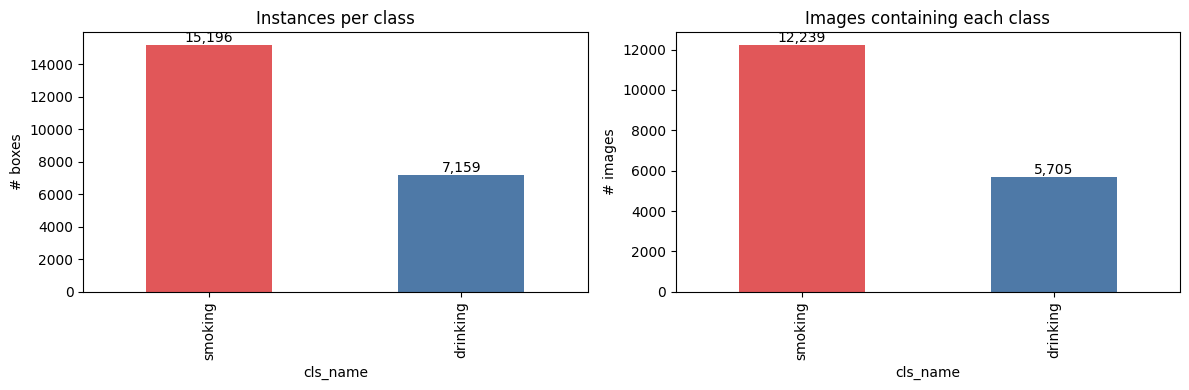

Instance imbalance ratio (max/min): 2.12x
→ Notable imbalance. Class-balanced augmentation (Section 10) will help even this out.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

inst["cls_name"].value_counts().reindex(UNIFIED_CLASSES).plot(
    kind="bar", ax=ax[0], color=["#e15759", "#4e79a7"])
ax[0].set_title("Instances per class"); ax[0].set_ylabel("# boxes")
for i, v in enumerate(inst["cls_name"].value_counts().reindex(UNIFIED_CLASSES)):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

img_per_cls = inst.groupby("cls_name")["image"].nunique().reindex(UNIFIED_CLASSES)
img_per_cls.plot(kind="bar", ax=ax[1], color=["#e15759", "#4e79a7"])
ax[1].set_title("Images containing each class"); ax[1].set_ylabel("# images")
for i, v in enumerate(img_per_cls):
    ax[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

imbalance = inst["cls_name"].value_counts()
ratio = imbalance.max() / imbalance.min()
print(f"Instance imbalance ratio (max/min): {ratio:.2f}x")
if ratio > 1.5:
    print("→ Notable imbalance. Class-balanced augmentation (Section 10) will help even this out.")

### 7.2 Boxes per image — how crowded are scenes?

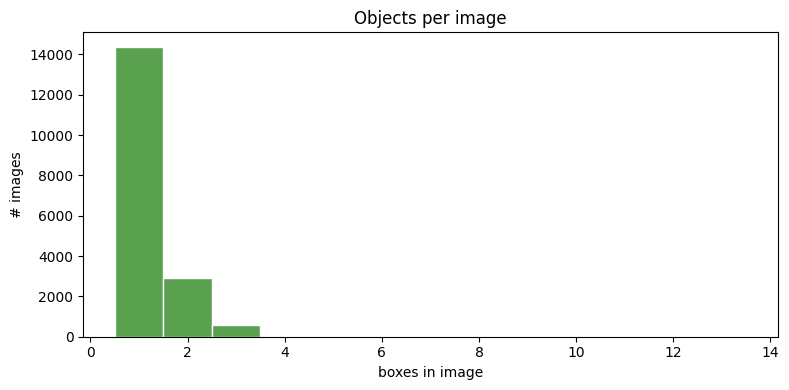

count    17944.00
mean         1.25
std          0.58
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         13.00


In [ ]:
boxes_per_img = inst.groupby("image").size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boxes_per_img, bins=range(1, boxes_per_img.max() + 2), align="left",
        color="#59a14f", edgecolor="white")
ax.set_title("Objects per image"); ax.set_xlabel("boxes in image"); ax.set_ylabel("# images")
plt.tight_layout(); plt.show()
print(boxes_per_img.describe().round(2).to_string())

### 7.3 Bounding-box geometry & small-object analysis

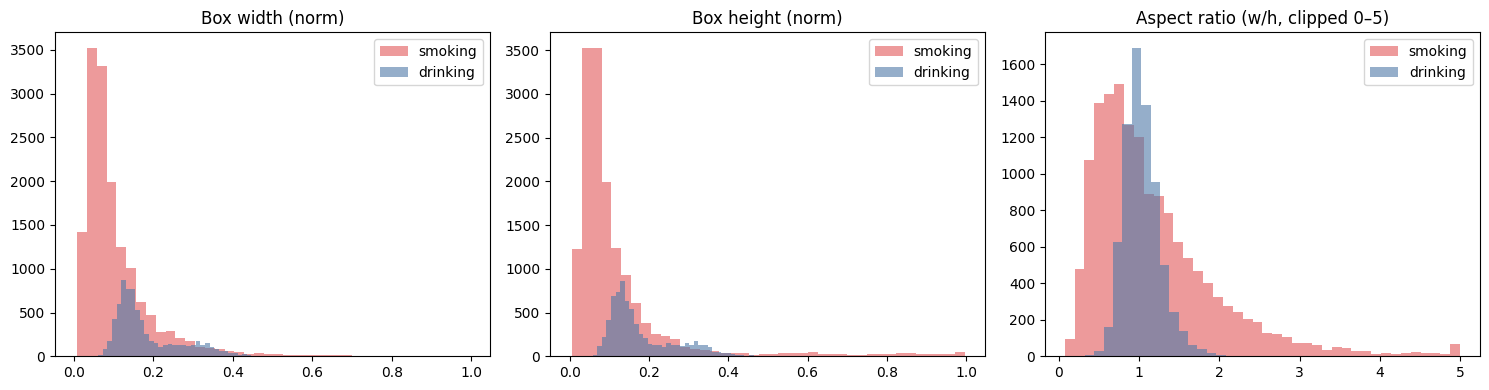

cls_name,drinking,smoking
size_bucket,,
tiny (<1%),320,10097
small (1–5%),5024,3861
medium (5–15%),1727,726
large (>15%),88,512


Share of tiny boxes (<1% of image): 46.6%
→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for cname, color in zip(UNIFIED_CLASSES, ["#e15759", "#4e79a7"]):
    sub = inst[inst["cls_name"] == cname]
    ax[0].hist(sub["w"], bins=40, alpha=0.6, label=cname, color=color)
    ax[1].hist(sub["h"], bins=40, alpha=0.6, label=cname, color=color)
    ax[2].hist(np.clip(sub["aspect"], 0, 5), bins=40, alpha=0.6, label=cname, color=color)
ax[0].set_title("Box width (norm)");  ax[1].set_title("Box height (norm)")
ax[2].set_title("Aspect ratio (w/h, clipped 0–5)")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

# COCO-style area buckets on normalized area (relative to image)
def bucket(a):
    if a < 0.01: return "tiny (<1%)"
    if a < 0.05: return "small (1–5%)"
    if a < 0.15: return "medium (5–15%)"
    return "large (>15%)"
inst["size_bucket"] = inst["area"].map(bucket)
order = ["tiny (<1%)", "small (1–5%)", "medium (5–15%)", "large (>15%)"]
display(pd.crosstab(inst["size_bucket"], inst["cls_name"]).reindex(order))
tiny_share = (inst["area"] < 0.01).mean()
print(f"Share of tiny boxes (<1% of image): {tiny_share:.1%}")
if tiny_share > 0.15:
    print("→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.")

### 7.4 Spatial prior — where do objects sit in the frame?

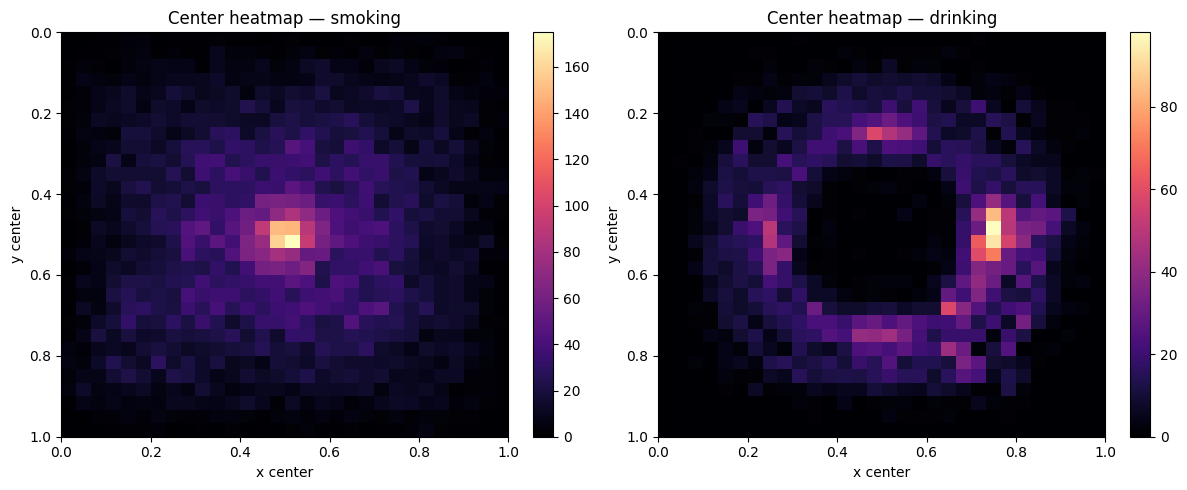

In [ ]:
fig, ax = plt.subplots(1, len(UNIFIED_CLASSES), figsize=(6 * len(UNIFIED_CLASSES), 5))
if len(UNIFIED_CLASSES) == 1: ax = [ax]
for a, cname in zip(ax, UNIFIED_CLASSES):
    sub = inst[inst["cls_name"] == cname]
    h = a.hist2d(sub["xc"], sub["yc"], bins=30, range=[[0, 1], [0, 1]], cmap="magma")
    a.set_title(f"Center heatmap — {cname}")
    a.set_xlabel("x center"); a.set_ylabel("y center"); a.invert_yaxis()
    fig.colorbar(h[3], ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

### 7.5 Per-dataset comparison — domain / annotation-style shift

If dataset A and B disagree sharply on box sizes or image resolution, the model may overfit to
one source's style. This is the check that a naive "just concat them" workflow skips.

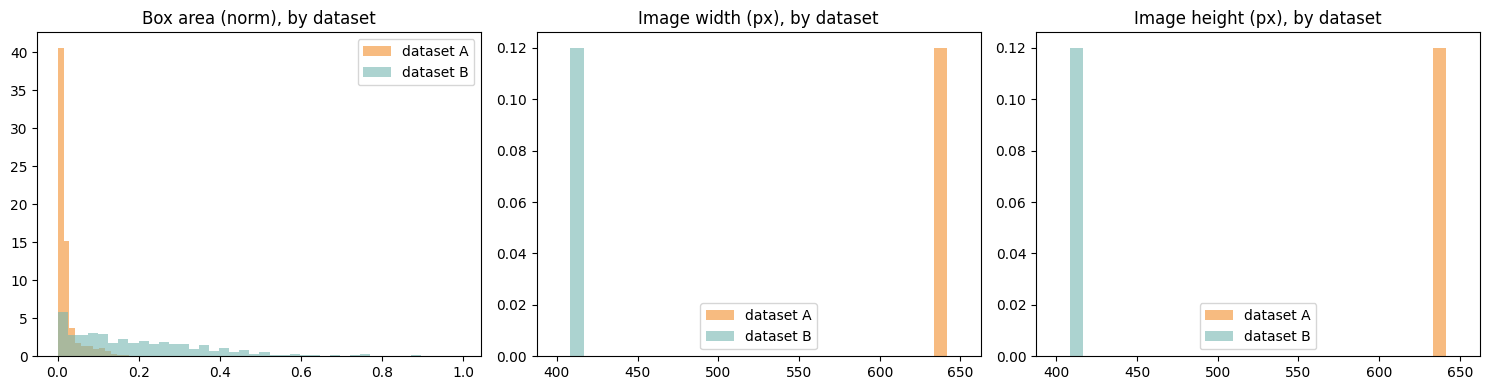

Class share by dataset:


cls_name,drinking,smoking
source,,
A,0.332,0.668
B,0.000,1.000


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for s, color in zip(["A", "B"], ["#f28e2b", "#76b7b2"]):
    sub = inst[inst["source"] == s]
    ax[0].hist(sub["area"], bins=40, alpha=0.6, label=f"dataset {s}", color=color, density=True)
    # Set an explicit range for image dimensions to include common sizes like 416 and 640
    ax[1].hist(sub["img_w"].dropna(), bins=30, alpha=0.6, label=f"dataset {s}", color=color, density=True, range=(400, 650))
    ax[2].hist(sub["img_h"].dropna(), bins=30, alpha=0.6, label=f"dataset {s}", color=color, density=True, range=(400, 650))
ax[0].set_title("Box area (norm), by dataset")
ax[1].set_title("Image width (px), by dataset")
ax[2].set_title("Image height (px), by dataset")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

print("Class share by dataset:")
display(pd.crosstab(inst["source"], inst["cls_name"], normalize="index").round(3))

### 7.6 Visual sanity check — sample images with boxes drawn

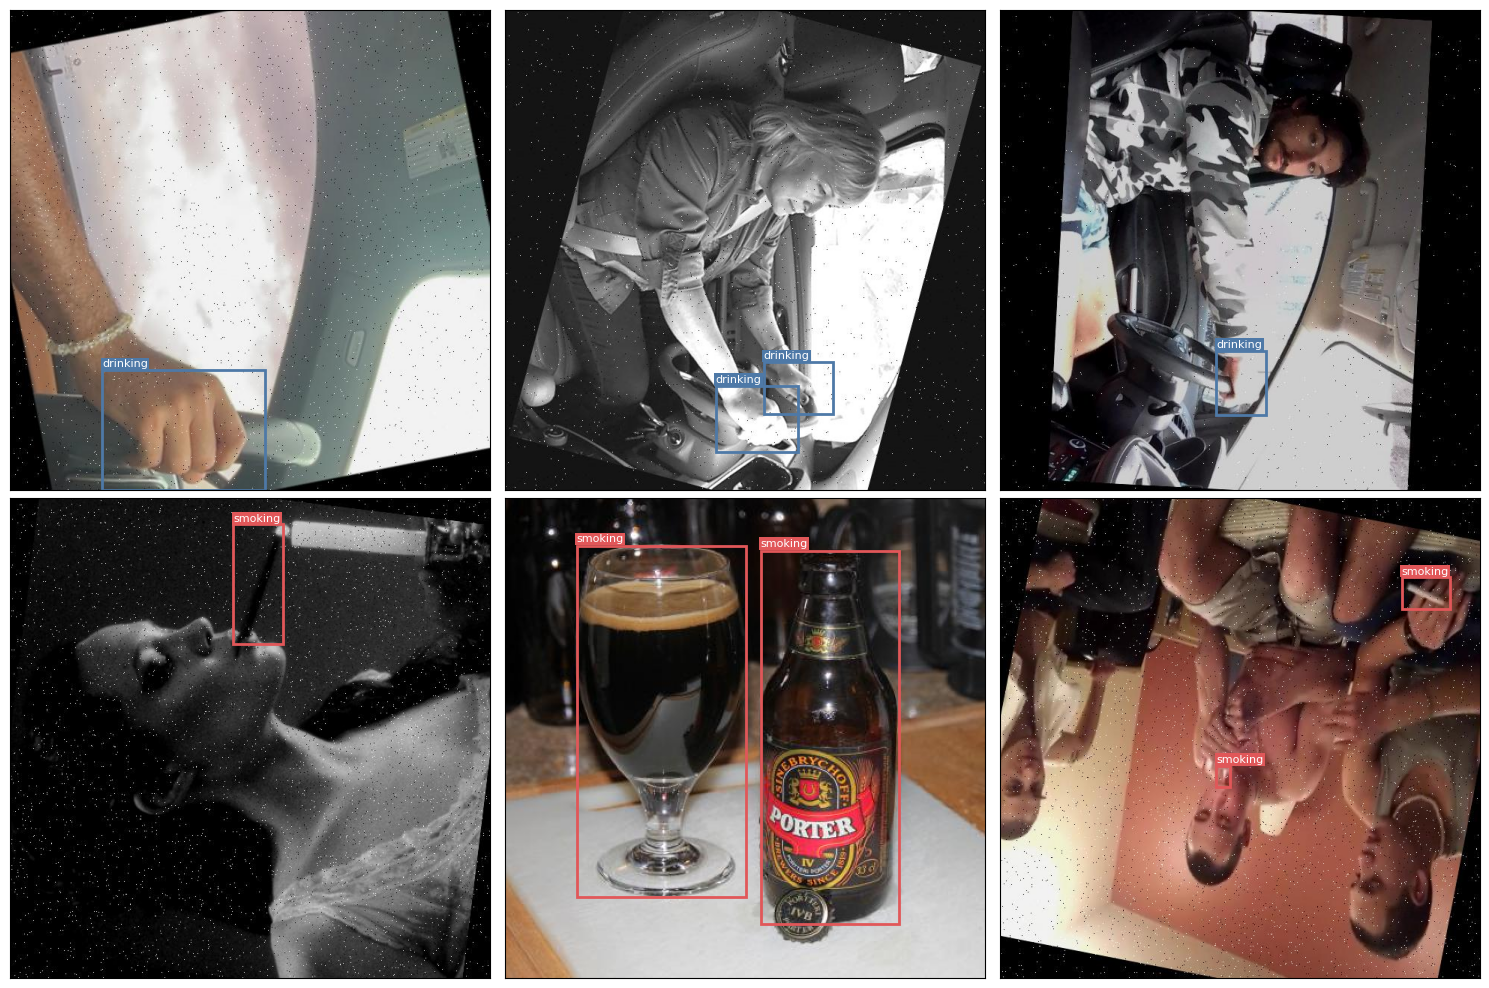

In [ ]:
def draw_sample(image_path, ax):
    im = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    ax.imshow(im)
    palette = {"smoking": "#e15759", "drinking": "#4e79a7"}
    for _, r in inst[inst["image"] == image_path].iterrows():
        x = (r["xc"] - r["w"] / 2) * W; y = (r["yc"] - r["h"] / 2) * H
        rect = patches.Rectangle((x, y), r["w"] * W, r["h"] * H,
                                 linewidth=2, edgecolor=palette.get(r["cls_name"], "lime"),
                                 facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 4, 0), r["cls_name"], color="white", fontsize=8,
                bbox=dict(facecolor=palette.get(r["cls_name"], "lime"), pad=1, edgecolor="none"))
    ax.set_xticks([]); ax.set_yticks([])

sample_imgs = (inst.groupby("cls_name")["image"].apply(
    lambda s: list(pd.Series(s.unique()).sample(min(3, s.nunique()), random_state=SEED)))
    ).explode().dropna().unique()[:6]

n = len(sample_imgs)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 5 * ((n + 2) // 3)))
for ax, p in zip(np.array(axes).ravel(), sample_imgs):
    draw_sample(p, ax)
for ax in np.array(axes).ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 8 · Deduplication (before splitting)

Merged datasets frequently share frames (same image scraped twice, or consecutive video frames).
If duplicates land on both sides of the split, val/test leak into train. We hash every image
(perceptual hash) and keep one representative per hash cluster.

In [ ]:
import imagehash
hash_map = defaultdict(list)
for p in inst["image"].unique():
    try:
        with Image.open(p) as im:
            hash_map[str(imagehash.phash(im))].append(p)
    except Exception:
        pass

dupes = {h: ps for h, ps in hash_map.items() if len(ps) > 1}
keep_images = {ps[0] for ps in hash_map.values()}      # one per cluster
n_dropped = inst["image"].nunique() - len(keep_images)
print(f"Duplicate clusters: {len(dupes)} | images dropped as duplicates: {n_dropped}")

inst = inst[inst["image"].isin(keep_images)].reset_index(drop=True)
print(f"Images after dedup: {inst['image'].nunique():,}")

Duplicate clusters: 412 | images dropped as duplicates: 592
Images after dedup: 17,352


## 9 · Train / val / test split (image-grouped, class-stratified)

The split is at the **image** level (all boxes of an image stay together) and stratified by each
image's **dominant class**, so rare-class images are proportionally represented in every split.
Deterministic via `SEED`.

In [ ]:
# dominant class per image (for stratification)
img_dom = (inst.groupby("image")["cls_name"]
                .agg(lambda s: s.value_counts().idxmax())
                .rename("dom_cls").reset_index())

rng = np.random.default_rng(SEED)
assign = {}
for cls, grp in img_dom.groupby("dom_cls"):
    imgs = grp["image"].tolist(); rng.shuffle(imgs)
    n = len(imgs)
    n_tr = int(round(n * SPLIT["train"]))
    n_va = int(round(n * SPLIT["val"]))
    for i, im in enumerate(imgs):
        assign[im] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")

inst["split"] = inst["image"].map(assign)
print("Images per split:")
display(inst.groupby("split")["image"].nunique().reindex(["train", "val", "test"]).to_frame("images"))
print("\nInstances per class per split:")
display(pd.crosstab(inst["split"], inst["cls_name"]).reindex(["train", "val", "test"]))

Images per split:


,images
split,
train,13882
val,1735
test,1735



Instances per class per split:


cls_name,drinking,smoking
split,,
train,5278,12058
val,650,1493
test,669,1487


## 10 · Augmentation — **train split only**, bbox-aware

Albumentations transforms images and their boxes together (`bbox_params` in YOLO format). The
pipeline uses only label-preserving ops for this task — geometric flips/scale/rotate plus
photometric jitter (lighting, colour, blur, noise) that mimics real capture conditions. We
**never** apply vertical flips (a person smoking upside-down isn't realistic) and keep rotation
mild.

If `BALANCE_CLASSES`, images whose dominant class is the minority get extra augmented copies, so
the exported train set is closer to balanced without touching val/test.

In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.85, 1.15), translate_percent=(0.0, 0.06),
             rotate=(-12, 12), shear=(-4, 4), fit_output=False, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.OneOf([A.MotionBlur(blur_limit=5), A.GaussianBlur(blur_limit=5),
             A.GaussNoise(var_limit=(10, 40))], p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"],
                            min_visibility=0.3, min_area=1e-4))

# minority multiplier
cls_counts = inst[inst.split == "train"]["cls_name"].value_counts()
minority = cls_counts.idxmin() if BALANCE_CLASSES else None
extra_for_minority = int(round(cls_counts.max() / max(cls_counts.min(), 1))) - 1 if BALANCE_CLASSES else 0
print("Base aug/image:", AUG_PER_IMAGE, "| minority class:", minority,
      "| extra copies for minority images:", extra_for_minority)

Base aug/image: 2 | minority class: drinking | extra copies for minority images: 1


## 11 · Export the YOLOv8 dataset

Writes the Ultralytics layout to `OUTPUT_ROOT`:

```
smoking_drinking_yolo/
├── data.yaml
├── images/{train,val,test}/
└── labels/{train,val,test}/
```

Originals are **copied** (never moved). Augmented variants are written **only into
`train/`** with an `_augN` suffix. Labels are rewritten with the unified class ids.

In [ ]:
import concurrent.futures
from tqdm.notebook import tqdm

out = Path(OUTPUT_ROOT)
for sub in ["images", "labels"]:
    for sp in ["train", "val", "test"]:
        (out / sub / sp).mkdir(parents=True, exist_ok=True)

def write_label(path, boxes):
    """boxes: list of (cls_id, xc, yc, w, h) already in unified ids."""
    lines = [f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c, x, y, w, h in boxes]
    path.write_text("\n".join(lines))

# group boxes per image (unified ids)
per_image = defaultdict(list)
img_split = {}
for _, r in inst.iterrows():
    per_image[r["image"]].append((int(r["cls_id"]), r["xc"], r["yc"], r["w"], r["h"]))
    img_split[r["image"]] = r["split"]
img_dom_map = dict(zip(img_dom["image"], img_dom["dom_cls"]))

def uniq_stem(src_path, source_tag):
    """avoid name collisions between datasets A and B"""
    return f"{source_tag}_{Path(src_path).stem}"

src_tag = dict(zip(inst["image"], inst["source"]))

def process_single_image(img_path, boxes):
    n_written_local = 0
    n_aug_local = 0

    sp = img_split[img_path]
    stem = uniq_stem(img_path, src_tag[img_path])
    ext = Path(img_path).suffix.lower()

    # 1) copy original
    shutil.copy(img_path, out / "images" / sp / f"{stem}{ext}")
    write_label(out / "labels" / sp / f"{stem}.txt", boxes)
    n_written_local += 1

    # 2) augment train only
    if sp == "train":
        reps = AUG_PER_IMAGE
        if BALANCE_CLASSES and img_dom_map.get(img_path) == minority:
            reps += extra_for_minority
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        yolo_boxes = [[b[1], b[2], b[3], b[4]] for b in boxes]
        labels = [b[0] for b in boxes]
        for k in range(reps):
            try:
                t = transform(image=image, bboxes=yolo_boxes, class_labels=labels)
            except Exception:
                continue
            if len(t["bboxes"]) == 0:  # all boxes fell outside crop -> skip
                continue
            aug_img = cv2.cvtColor(t["image"], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out / "images" / sp / f"{stem}_aug{k}{ext}"), aug_img)
            aug_boxes = [(lab, *bb) for bb, lab in zip(t["bboxes"], t["class_labels"])]
            write_label(out / "labels" / sp / f"{stem}_aug{k}.txt", aug_boxes)
            n_aug_local += 1

    return n_written_local, n_aug_local

n_written, n_aug = 0, 0
# Use ThreadPoolExecutor for parallel processing
with concurrent.futures.ThreadPoolExecutor() as executor:
    future_to_image = {
        executor.submit(process_single_image, img_path, boxes):
        img_path for img_path, boxes in per_image.items()
    }
    for future in tqdm(concurrent.futures.as_completed(future_to_image), total=len(per_image), desc="Processing images"):
        img_path = future_to_image[future]
        try:
            written_count, aug_count = future.result()
            n_written += written_count
            n_aug += aug_count
        except Exception as exc:
            print(f'{img_path} generated an exception: {exc}')

print(f"Originals written: {n_written} | augmented (train) written: {n_aug}")

# data.yaml
yaml_text = (
    f"path: {OUTPUT_ROOT}\n"
    f"train: images/train\nval: images/val\ntest: images/test\n\n"
    f"nc: {len(UNIFIED_CLASSES)}\n"
    f"names: {UNIFIED_CLASSES}\n"
)
(out / "data.yaml").write_text(yaml_text)
print("\ndata.yaml:\n" + yaml_text)


Processing images:   0%|          | 0/17352 [00:00<?, ?it/s]

Originals written: 17352 | augmented (train) written: 31935

data.yaml:
path: /content/drive/MyDrive/datasets/smoking_drinking_yolo
train: images/train
val: images/val
test: images/test

nc: 2
names: ['smoking', 'drinking']



---
### Handoff notes

* **`data.yaml`** is the single entry point for Ultralytics — point training at it.
* **Val/test are augmentation-free and duplicate-free**, so reported metrics reflect real
  generalization.
* If EDA flagged heavy class imbalance that augmentation didn't fully fix, also pass class
  weights or oversample at train time.
* If the tiny-object share was high, bump `imgsz` (832–960) when training.
* Re-run only the Config cell to regenerate with different split ratios or augmentation strength —
  the rest is deterministic.